In [1]:
import torch
import torch.nn as nn
import torchvision

from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


In [3]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

28×28 Image

↓

Conv2D

↓

ReLU

↓

MaxPool

↓

Conv2D

↓

ReLU

↓

MaxPool

↓

Flatten

↓

Linear

↓

10 Classes


In [5]:
class CNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7,128),

            nn.ReLU(),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

model = CNNModel().to(device)

print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


Input Image

↓

Small Filter (Kernel)

↓

Detect Edges

↓

Feature Map

In [6]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [8]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [9]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return epoch_loss, accuracy

In [10]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    loss, acc = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    train_losses.append(loss)
    train_accuracies.append(acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss = {loss:.4f}"
        f" | Accuracy = {acc:.2f}%"
    )

Epoch 1/5 | Loss = 0.1679 | Accuracy = 94.96%
Epoch 2/5 | Loss = 0.0471 | Accuracy = 98.57%
Epoch 3/5 | Loss = 0.0334 | Accuracy = 98.96%
Epoch 4/5 | Loss = 0.0232 | Accuracy = 99.23%
Epoch 5/5 | Loss = 0.0190 | Accuracy = 99.38%


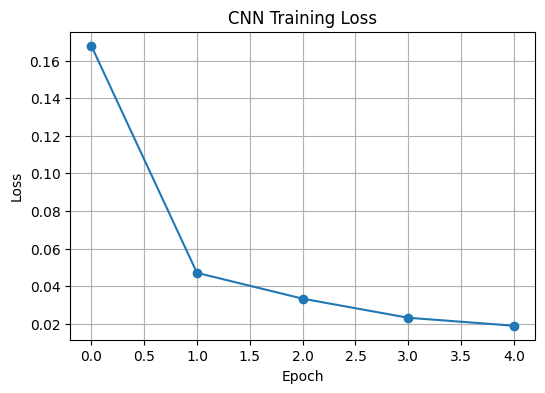

In [11]:
plt.figure(figsize=(6,4))

plt.plot(train_losses, marker="o")

plt.title("CNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

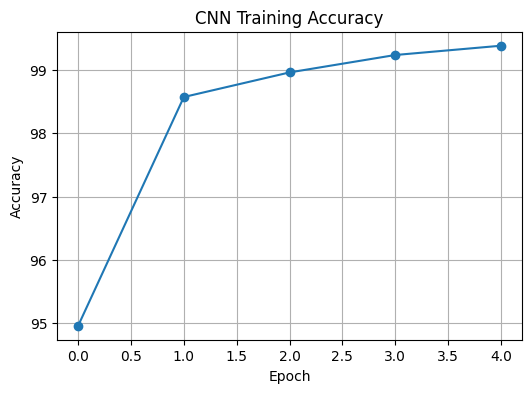

In [12]:
plt.figure(figsize=(6,4))

plt.plot(train_accuracies, marker="o")

plt.title("CNN Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 99.00%


In [14]:
torch.save(model.state_dict(), "mnist_cnn.pth")

print("CNN model saved successfully!")

CNN model saved successfully!


# CNN vs MLP Comparison

| Feature | MLP | CNN |
|---------|-----|-----|
| Uses Image Structure | ❌ | ✅ |
| Learns Edges | ❌ | ✅ |
| Learns Shapes | ❌ | ✅ |
| Better Accuracy | ❌ | ✅ |
| Best for Images | ❌ | ✅ |

## Reflection

Compared to the previous MLP model, the CNN architecture preserves spatial information and automatically learns important image features using convolution layers. This results in better performance on image classification tasks.

# DAY 5 Summary

## Project
MNIST Handwritten Digit Classification using CNN

## What I Learned

- Built a Convolutional Neural Network (CNN)
- Understood Conv2D, ReLU, and MaxPooling layers
- Trained the CNN using the Adam optimizer
- Evaluated performance on the MNIST test dataset
- Compared CNN with a fully connected MLP model
- Saved the trained CNN model

## Final Results

| Metric | Value |
|--------|------:|
| Epochs | 5 |
| Final Training Accuracy | 99.38% |
| Final Test Accuracy | 99.00% |

## Key Takeaway

CNN preserved the spatial information of images and achieved better performance than the previous MLP model.